# Reviewing ERA5 data for OND, JJAS and MAM

This notebook reviews the rainfall data for the 3 seasons and looks at the driest years to get years to calibrate the trigger against.

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import ocha_stratus as stratus
from src.datasources.era5 import fetch_era5_data
from src.datasources.seas5 import fetch_seas5_data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import calendar

In [3]:
ond_blob_name = "ds-aa-eth-drought/exploration/Ethiopia OND zones.csv"
mam_blob_name = "ds-aa-eth-drought/exploration/Ethiopia MAM zones.csv"
jjas_blob_name = "ds-aa-eth-drought/exploration/Ethiopia JJAS zones.csv"
ond_validation_data = (
    "ds-aa-eth-drought/exploration/Ethiopia Drought Validation Data OND.csv"
)
mam_validation_data = (
    "ds-aa-eth-drought/exploration/Ethiopia Drought Validation Data MAM.csv"
)
jjas_validation_data = (
    "ds-aa-eth-drought/exploration/Ethiopia Drought Validation Data JJAS.csv"
)
# maproom hindcasts
somali_mam_maproom_hindcast = "ds-aa-eth-drought/exploration/WFP Ethiopia AA MAM Trigger Documentation and Metrics - Somali Region.csv"
somali_ond_maproom_hindcast = "ds-aa-eth-drought/exploration/WFP Ethiopia AA OND Trigger Documentation and Metrics - Somali Region.csv"
oromia_mam_maproom_hindcast = "ds-aa-eth-drought/exploration/WFP FbF Ethiopia 2023 MAM Trigger Documentation and Metrics - Oromia Region.csv"
oromia_ond_maproom_hindcast = "ds-aa-eth-drought/exploration/WFP AA Ethiopia OND Trigger Documentation and Metrics - Oromia Region (1).csv"
start_date = pd.Timestamp("1997-01-01")
end_date = pd.Timestamp("2025-09-01")
ond_months = [10, 11, 12]
mam_months = [3, 4, 5]
jjas_months = [6, 7, 8, 9]

In [4]:
# plot the admin bounds for each season
eth_adm2 = stratus.codab.load_codab_from_fieldmaps("ETH", admin_level=2)
eth_adm0 = stratus.codab.load_codab_from_fieldmaps("ETH", admin_level=0)

In [5]:
# make a function to run the code below for each season
def analyze_season(blob_name, season_name, season_months):
    season_csv = stratus.load_csv_from_blob(
        blob_name, stage="dev", container_name="projects"
    )
    # Fetch ERA5 data for the specified woredas and date range
    seasonal_rainfall = fetch_era5_data(
        season_csv["adm2_pcode"].unique(), start_date=start_date, end_date=end_date
    )
    # adding month to the seasonal_rainfall dataframe for easier analysis
    seasonal_rainfall["month"] = pd.to_datetime(
        seasonal_rainfall["valid_date"]
    ).dt.month
    seasonal_rainfall["year"] = pd.to_datetime(seasonal_rainfall["valid_date"]).dt.year
    # extracting values for only the season months
    seasonal_rainfall_months = seasonal_rainfall[
        seasonal_rainfall["month"].isin(season_months)
    ].copy()
    seasonal_rainfall_months.loc[:, "month_name"] = seasonal_rainfall_months[
        "month"
    ].apply(lambda m: calendar.month_abbr[m])
    # summing the mean column by year for all adm2_pcode
    seasonal_rainfall_summed = (
        seasonal_rainfall_months.groupby(["month", "year"])
        .agg({"mean": "sum"})
        .reset_index()
    )
    # plot the values as a bar chart
    # stack the values yearly and color each month differently
    # add total values on top of each bar

    fig, ax = plt.subplots(figsize=(12, 4))
    months = seasonal_rainfall_summed["month"].unique()
    bottom = None
    for month in months:
        month_data = seasonal_rainfall_summed[
            seasonal_rainfall_summed["month"] == month
        ]
        ax.bar(
            month_data["year"],
            month_data["mean"],
            bottom=bottom,
            label=calendar.month_abbr[month],
            alpha=0.6,
        )
        if bottom is None:
            bottom = month_data["mean"].values
        else:
            bottom += month_data["mean"].values
    for i, year in enumerate(seasonal_rainfall_summed["year"].unique()):
        total = seasonal_rainfall_summed[seasonal_rainfall_summed["year"] == year][
            "mean"
        ].sum()
        ax.text(year, total + 2, f"{total:.0f}", ha="center", va="bottom", fontsize=7.5)
    ax.set_title(f"Seasonal Rainfall ({season_name}) by Year - Averaged over Zones")
    ax.set_xlabel("Year")
    ax.set_ylabel("Total Rainfall (mm)")
    ax.legend(title="Month")
    plt.show()

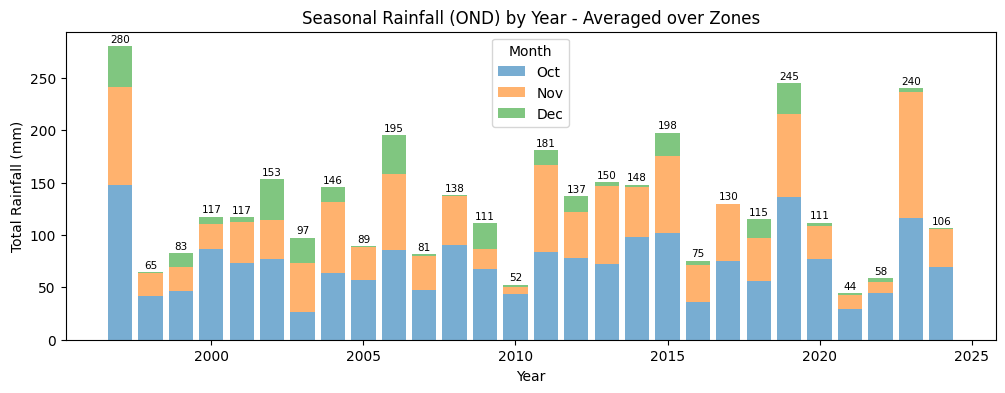

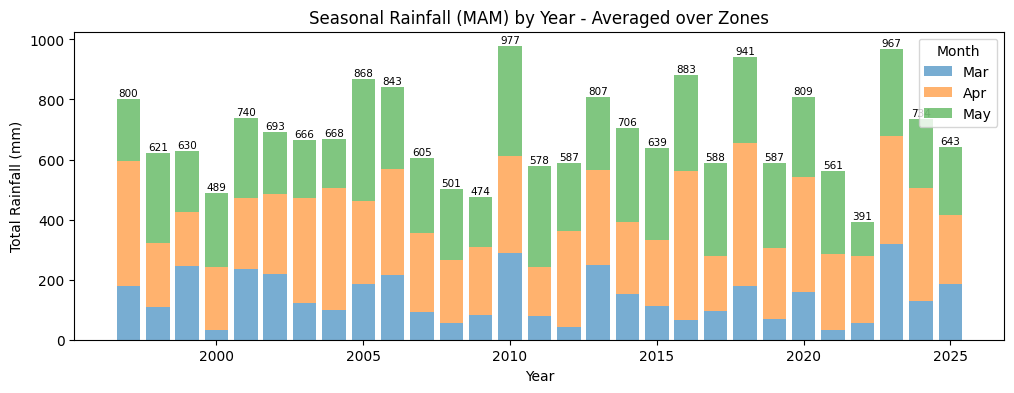

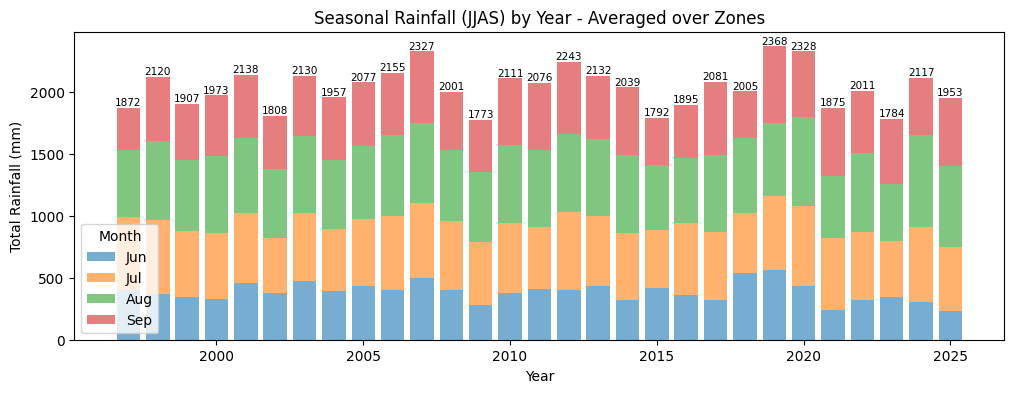

In [6]:
analyze_season(ond_blob_name, "OND", ond_months)
analyze_season(mam_blob_name, "MAM", mam_months)
analyze_season(jjas_blob_name, "JJAS", jjas_months)

In [7]:
def build_season_table(
    seas5_data,
    validation_csv,
    era5_data,
    season_name,
    season_months,
    lead_time_map,
    rp_threshold=5,
    val_cols=("CERF Allocations", "People Affected"),
    plot_heatmap=False,
    plot_skill=False,
    highlight_value=None,
    N_events=7,
):
    df = seas5_data.copy()
    all_years = list(range(1997, 2026))
    df["issued_month"] = pd.to_datetime(df["issued_date"]).dt.month
    df["valid_month"] = pd.to_datetime(df["valid_date"]).dt.month
    df["valid_year"] = pd.to_datetime(df["valid_date"]).dt.year

    df = df[
        (df["valid_month"].isin(season_months))
        & (df["issued_month"].isin(lead_time_map.keys()))
    ].copy()

    df = df.groupby(["pcode", "valid_year", "issued_month"])["mean"].sum().reset_index()
    df["lead_time"] = df["issued_month"].map(lead_time_map)

    df["rank"] = df.groupby(["pcode", "issued_month"])["mean"].rank(
        method="min", ascending=True
    )
    n = df["valid_year"].nunique()
    df["return_period"] = ((n + 1) / df["rank"]).round(1)

    drought_counts = (
        df[df["return_period"] >= rp_threshold]
        .groupby(["valid_year", "lead_time"])
        .size()
        .reset_index(name="drought_zone_count")
    )

    era = era5_data.copy()
    era["valid_month"] = pd.to_datetime(era["valid_date"]).dt.month
    era["valid_year"] = pd.to_datetime(era["valid_date"]).dt.year

    era = era[era["valid_month"].isin(season_months)].copy()

    era = era.groupby(["pcode", "valid_year"])["mean"].sum().reset_index()

    era["rank"] = era.groupby("pcode")["mean"].rank(method="min", ascending=True)
    n2 = era["valid_year"].nunique()
    era["return_period"] = ((n2 + 1) / era["rank"]).round(1)

    era_drought = (
        era[era["return_period"] >= rp_threshold]
        .groupby("valid_year")
        .size()
        .reset_index(name="drought_zone_count")
    )
    era_drought["lead_time"] = 0

    combined = pd.concat([drought_counts, era_drought], ignore_index=True)

    table = combined.pivot_table(
        index="valid_year",
        columns="lead_time",
        values="drought_zone_count",
        fill_value="",
    ).reset_index()

    table = table.merge(
        validation_csv, left_on="valid_year", right_on="year", how="outer"
    )
    table = table.drop_duplicates(subset=["year"], keep="first")
    table = table.set_index("year").reindex(all_years).reset_index()
    era_rain = era.groupby("valid_year")["mean"].sum().reset_index()
    era_rain = era_rain.rename(columns={"mean": "era5_rainfall"})
    table = table.merge(era_rain, left_on="year", right_on="valid_year", how="outer")
    rename_map = {}
    for issued_month, lt in lead_time_map.items():
        rename_map[lt] = f"Lead Time {lt} ({calendar.month_abbr[issued_month]})"
    rename_map[0] = "ERA5 (Observed)"

    table = table.rename(columns=rename_map)

    for col in ["valid_year", "Season", "season", "Season_x", "Season_y"]:
        if col in table.columns:
            table = table.drop(columns=[col])

    table = table.apply(
        lambda col: (
            col.round(0)
            if col.dtype in ("float64", "float32", "int64", "int32")
            else col
        )
    )

    table = table.replace(np.nan, "")

    lt_cols = [c for c in table.columns if c.startswith("Lead Time")]
    lt_sorted = sorted(lt_cols, key=lambda x: -int(x.split()[2]))

    final_cols = (
        ["year", "era5_rainfall"] + lt_sorted + ["ERA5 (Observed)"] + list(val_cols)
    )
    final_cols = [c for c in final_cols if c in table.columns]

    table = table[final_cols]
    # order table by era5 rainfall
    table = table.drop_duplicates(subset=["year"], keep="first")
    table = table.set_index("year").reindex(all_years).reset_index()
    table = table.rename(columns={"index": "year"})
    table["era5_rainfall"] = pd.to_numeric(table["era5_rainfall"], errors="coerce")
    table = table.sort_values("era5_rainfall")
    table = table.replace(np.nan, "")

    non_val_cols = [c for c in final_cols if c not in val_cols]
    for c in non_val_cols:
        if c in table.columns:
            table[c] = table[c].apply(
                lambda x: f"{x:.0f}" if isinstance(x, (int, float)) else x
            )
    for c in val_cols:
        if c in table.columns:
            table[c] = table[c].apply(
                lambda x: f"{x:,.0f}" if isinstance(x, (int, float)) else x
            )

    if plot_heatmap:
        pivot = combined.pivot(
            index="lead_time", columns="valid_year", values="drought_zone_count"
        )
        pivot = pivot.reindex(columns=all_years)
        pivot = pivot.reindex(sorted(pivot.index, reverse=True))

        # map integers → month names + ERA5
        lt_map = {lt: calendar.month_abbr[m] for m, lt in lead_time_map.items()}
        lt_map[0] = "ERA5"

        pivot.index = pivot.index.map(lt_map)

        plt.figure(figsize=(14, 5))
        sns.heatmap(pivot, annot=True, cmap="YlOrRd", fmt="g")
        plt.title(
            f"Number of Zones drier than 1-in-{rp_threshold}yr RP — {season_name} Season (SEAS5 + ERA5)"
        )
        plt.xlabel("Valid Year")
        plt.ylabel("Source / Lead Time")
        plt.tight_layout()
        plt.show()

    if plot_skill:
        # exclude ERA5 (lead_time=0)
        fcst_only = combined[combined["lead_time"] != 0].copy()

        # lead times sorted high→low
        lts = sorted(fcst_only["lead_time"].unique(), reverse=True)

        # max threshold (same across all LTs)
        max_zones = int(fcst_only["drought_zone_count"].max())

        # observed drought counts per year (for all T)
        obs_by_year = era_drought.set_index("valid_year")["drought_zone_count"]

        # ---- Create 2×2 subplot grid ----
        fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
        axes = axes.flatten()

        # for each LT
        for ax, lt in zip(axes, lts):

            df_lt = fcst_only[fcst_only["lead_time"] == lt]
            years = sorted(all_years)

            thresholds = np.arange(1, max_zones + 1)
            hit_rates = []
            false_rates = []
            miss_rates = []

            for T in thresholds:
                # forecast drought = 1 if >= T zones
                fc = (
                    df_lt.set_index("valid_year")["drought_zone_count"]
                    .reindex(years)
                    .fillna(0)
                )
                fc = fc.apply(lambda z: 1 if z >= T else 0)

                # observed drought
                era_rain = era.groupby("valid_year")["mean"].sum().reset_index()
                era_rain["rank"] = era_rain["mean"].rank(method="first", ascending=True)

                obs_event = (
                    era_rain.set_index("valid_year")["rank"]
                    .reindex(all_years)
                    .fillna(np.inf)  # years outside ERA range → non-event
                    .apply(lambda r: 1 if r <= N_events else 0)
                )
                obs = obs_event
                # obs = obs_by_year.reindex(years).fillna(0)
                # obs = obs.apply(lambda z: 1 if z >= T else 0)

                # contingency table
                hits = ((fc == 1) & (obs == 1)).sum()
                misses = ((fc == 0) & (obs == 1)).sum()
                false_alarms = ((fc == 1) & (obs == 0)).sum()
                correct_neg = ((fc == 0) & (obs == 0)).sum()

                HR = hits / (hits + misses) if (hits + misses) > 0 else 0
                FAR = (
                    false_alarms / (false_alarms + correct_neg)
                    if (false_alarms + correct_neg) > 0
                    else 0
                )
                MR = misses / (hits + misses) if (hits + misses) > 0 else 0

                hit_rates.append(HR)
                false_rates.append(FAR)
                miss_rates.append(MR)

            if highlight_value is not None:
                T = int(highlight_value)

                if T <= max(thresholds):

                    # vertical line
                    ax.axvline(T, color="red", linestyle="--", linewidth=1.5, alpha=0.8)

                    # add markers for HR / FAR / MR
                    ax.scatter(
                        [T],
                        [hit_rates[T - 1]],
                        color="black",
                        s=60,
                    )
                    ax.scatter(
                        [T],
                        [false_rates[T - 1]],
                        color="black",
                        s=60,
                    )
                    ax.scatter(
                        [T],
                        [miss_rates[T - 1]],
                        color="black",
                        s=60,
                    )

                    # optional annotation
                    ax.text(
                        T + 0.1,
                        hit_rates[T - 1],
                        f"HR={hit_rates[T-1]:.2f}",
                        color="black",
                    )
                    ax.text(
                        T + 0.1,
                        false_rates[T - 1],
                        f"FAR={false_rates[T-1]:.2f}",
                        color="black",
                    )
                    ax.text(
                        T + 0.1,
                        miss_rates[T - 1],
                        f"MR={miss_rates[T-1]:.2f}",
                        color="black",
                    )

            # plot lines only
            ax.plot(thresholds, hit_rates, label="Hit Rate", linewidth=2)
            ax.plot(thresholds, false_rates, label="False Alarm Rate", linewidth=2)
            ax.plot(thresholds, miss_rates, label="Miss Rate", linewidth=2)

            issued_month = [m for m, l in lead_time_map.items() if l == lt][0]
            issued_label = calendar.month_abbr[issued_month]
            ax.set_title(f"Issued in {issued_label}")
            ax.grid(alpha=0.3)

        # shared labels
        fig.add_subplot(111, frameon=False)
        plt.tick_params(
            labelcolor="none", top=False, bottom=False, left=False, right=False
        )
        plt.xlabel("Threshold (Number of Zones)")
        plt.ylabel("Metric Value")

        # single legend
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper center", ncol=3)

        plt.tight_layout()
        plt.show()

    if highlight_value is not None:
        # columns that hold drought zone counts
        drought_cols = [
            c
            for c in table.columns
            if c.startswith("Lead Time") or c == "ERA5 (Observed)"
        ]

        def color_if_exceeds(val):
            try:
                v = float(val)
                return "background-color: red" if v >= highlight_value else ""
            except:
                return ""

        styled = table.style.map(color_if_exceeds, subset=drought_cols)
        return styled

    if highlight_value is not None:

        # Ensure threshold is integer
        T = int(highlight_value)

        # Collect for each lead time
        rows = []

        # Use forecast-only (exclude ERA5)
        fcst_only = combined[combined["lead_time"] != 0].copy()

        # Observed drought counts
        obs_by_year = era_drought.set_index("valid_year")["drought_zone_count"]

        for lt in sorted(fcst_only["lead_time"].unique(), reverse=True):

            df_lt = fcst_only[fcst_only["lead_time"] == lt]
            years = sorted(all_years)

            # forecast binary
            fc = (
                df_lt.set_index("valid_year")["drought_zone_count"]
                .reindex(years)
                .fillna(0)
            )
            fc = fc.apply(lambda z: 1 if z >= T else 0)

            # observed binary
            obs = obs_by_year.reindex(years).fillna(0)
            obs = obs.apply(lambda z: 1 if z >= T else 0)

            # contingency
            hits = ((fc == 1) & (obs == 1)).sum()
            misses = ((fc == 0) & (obs == 1)).sum()
            false_alarms = ((fc == 1) & (obs == 0)).sum()
            correct_neg = ((fc == 0) & (obs == 0)).sum()

            HR = hits / (hits + misses) if (hits + misses) > 0 else 0
            FAR = (
                false_alarms / (false_alarms + correct_neg)
                if (false_alarms + correct_neg) > 0
                else 0
            )
            MR = misses / (hits + misses) if (hits + misses) > 0 else 0

            issued_month = [m for m, l in lead_time_map.items() if l == lt][0]
            issued_label = calendar.month_abbr[issued_month]

            rows.append(
                {
                    "Lead Time": lt,
                    "Issued": issued_label,
                    "Threshold (zones)": T,
                    "Hit Rate": round(HR, 2),
                    "False Alarm Rate": round(FAR, 2),
                    "Miss Rate": round(MR, 2),
                }
            )

        summary_df = pd.DataFrame(rows)

    return table

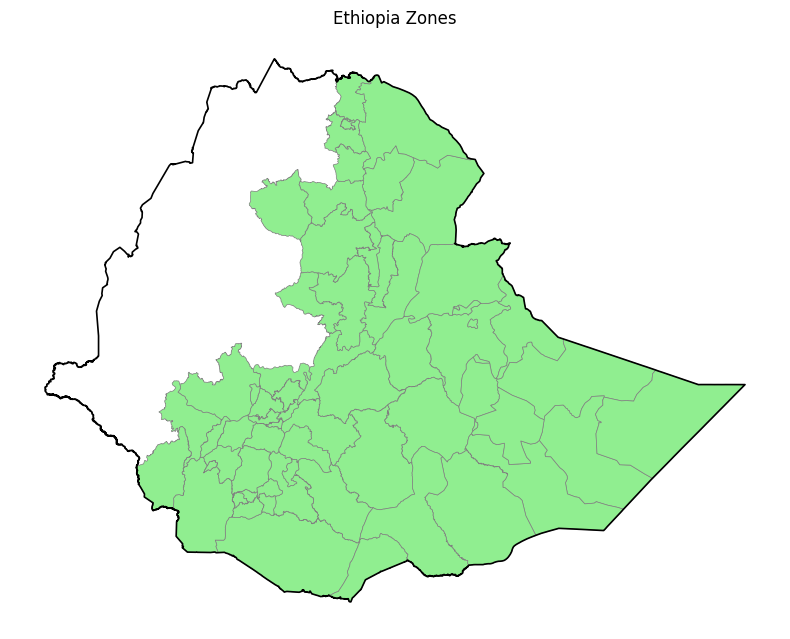

In [8]:
season_csv = stratus.load_csv_from_blob(
    mam_blob_name, stage="dev", container_name="projects"
)
seas5_data = fetch_seas5_data(
    season_csv["adm2_pcode"].unique(), start_date=start_date, end_date=end_date
)
era5_data = fetch_era5_data(
    season_csv["adm2_pcode"].unique(), start_date=start_date, end_date=end_date
)
era5_data["year"] = pd.to_datetime(era5_data["valid_date"]).dt.year
# validation data (CERF + EMDAT)
validation_csv = stratus.load_csv_from_blob(
    mam_validation_data, stage="dev", container_name="projects"
)
validation_csv["year"] = validation_csv["Season"].str[-4:].astype(int)
# plot the admins
fig, ax = plt.subplots(figsize=(8, 8))
eth_adm2[eth_adm2["adm2_src"].isin(season_csv["adm2_pcode"])].plot(
    ax=ax, edgecolor="grey", facecolor="lightgreen", linewidth=0.5
)
eth_adm0.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=1.2)
ax.set_title("Ethiopia Zones")
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [9]:
# unique zones per season
len(season_csv["adm2_pcode"].unique())

62

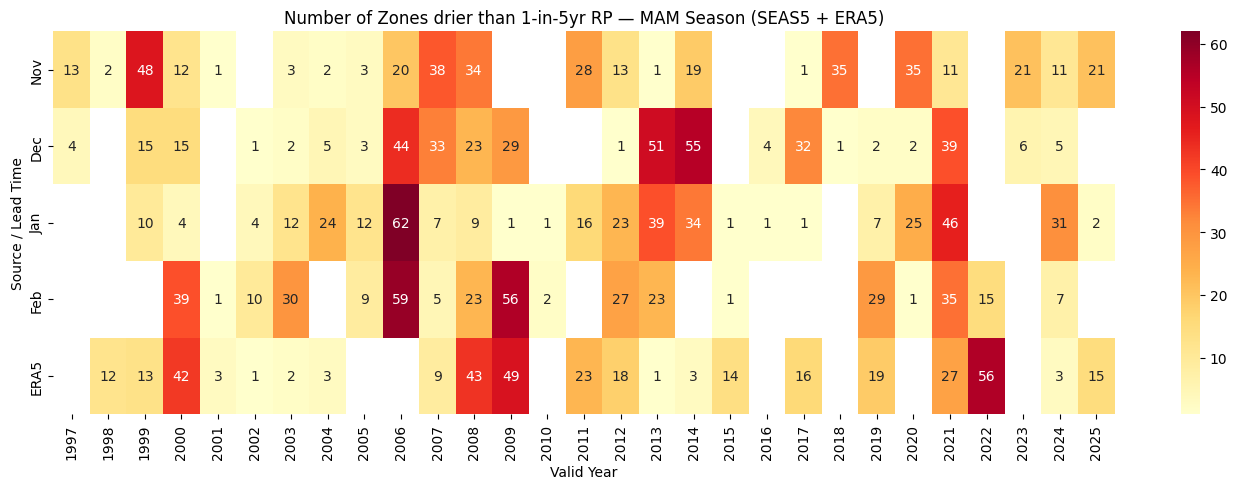

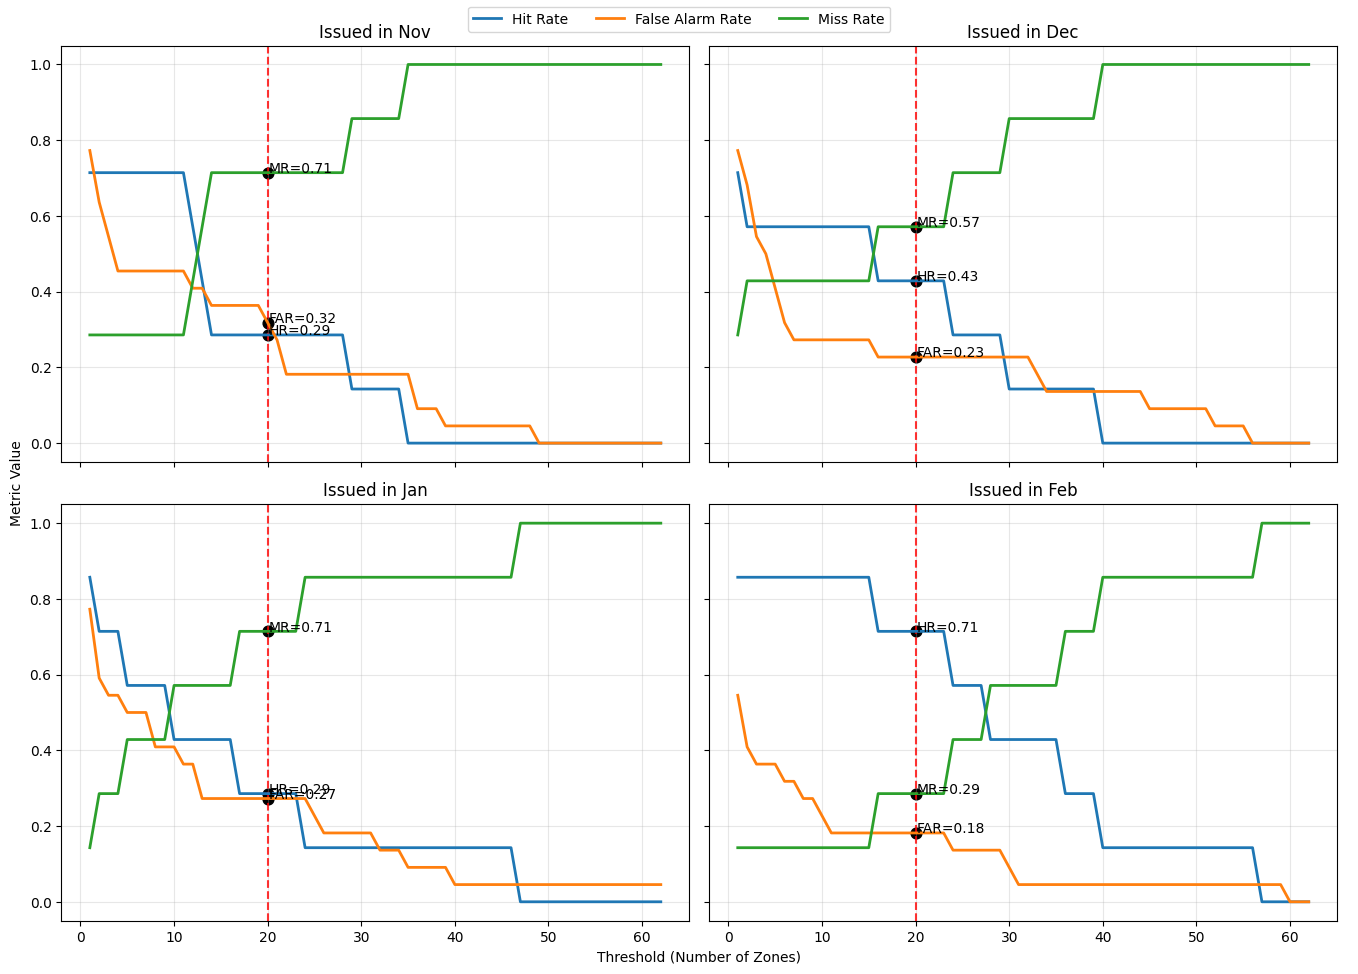

,year,era5_rainfall,Lead Time 4 (Nov),Lead Time 3 (Dec),Lead Time 2 (Jan),Lead Time 1 (Feb),ERA5 (Observed),CERF Allocations,People Affected
25,2022,391,,,,15,56,"11,999,748","24,100,000"
12,2009,474,,29,1,56,49,,"6,200,000"
3,2000,489,12,15,4,39,42,,
11,2008,501,34,23,9,23,43,"19,999,594","6,400,000"
24,2021,561,11,39,46,35,27,"19,996,683","6,800,000"
14,2011,578,28,,16,,23,"14,598,379","4,805,679"
22,2019,587,,2,7,29,19,"9,998,667",
15,2012,587,13,1,23,27,18,,"1,000,000"
20,2017,588,1,32,1,,16,"10,000,000",
10,2007,605,38,33,7,5,9,,


In [10]:
mam_table = build_season_table(
    seas5_data=seas5_data,
    validation_csv=validation_csv,
    era5_data=era5_data,
    season_name="MAM",
    season_months=[3, 4, 5],
    lead_time_map={11: 4, 12: 3, 1: 2, 2: 1},
    plot_heatmap=True,
    plot_skill=True,
    highlight_value=20,
    N_events=7,
)

mam_table

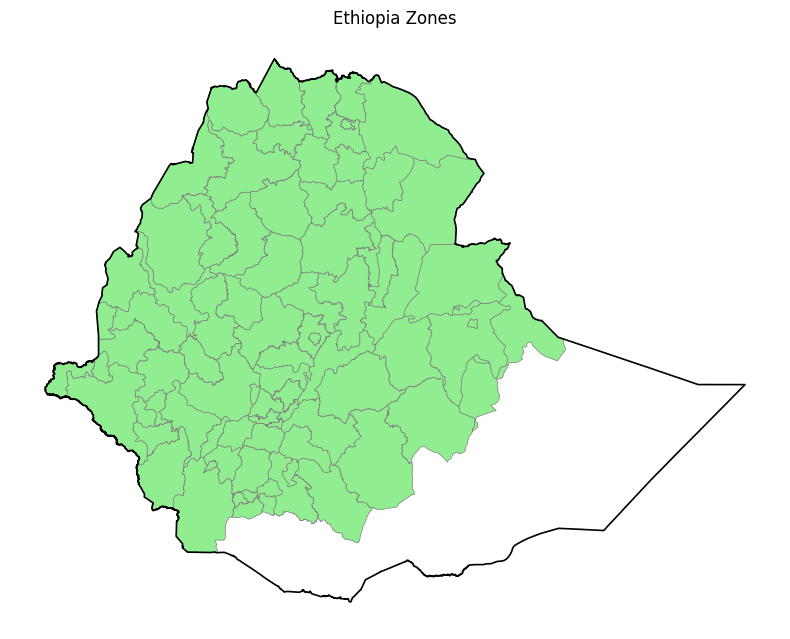

In [11]:
season_csv = stratus.load_csv_from_blob(
    jjas_blob_name, stage="dev", container_name="projects"
)
seas5_data = fetch_seas5_data(
    season_csv["adm2_pcode"].unique(), start_date=start_date, end_date=end_date
)
era5_data = fetch_era5_data(
    season_csv["adm2_pcode"].unique(), start_date=start_date, end_date=end_date
)
era5_data["year"] = pd.to_datetime(era5_data["valid_date"]).dt.year
# validation data (CERF + EMDAT)
validation_csv = stratus.load_csv_from_blob(
    jjas_validation_data, stage="dev", container_name="projects"
)
validation_csv["year"] = validation_csv["Season"].str[-4:].astype(int)
# plot the admins
fig, ax = plt.subplots(figsize=(8, 8))
eth_adm2[eth_adm2["adm2_src"].isin(season_csv["adm2_pcode"])].plot(
    ax=ax, edgecolor="grey", facecolor="lightgreen", linewidth=0.5
)
eth_adm0.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=1.2)
ax.set_title("Ethiopia Zones")
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [12]:
len(season_csv["adm2_pcode"].unique())

83

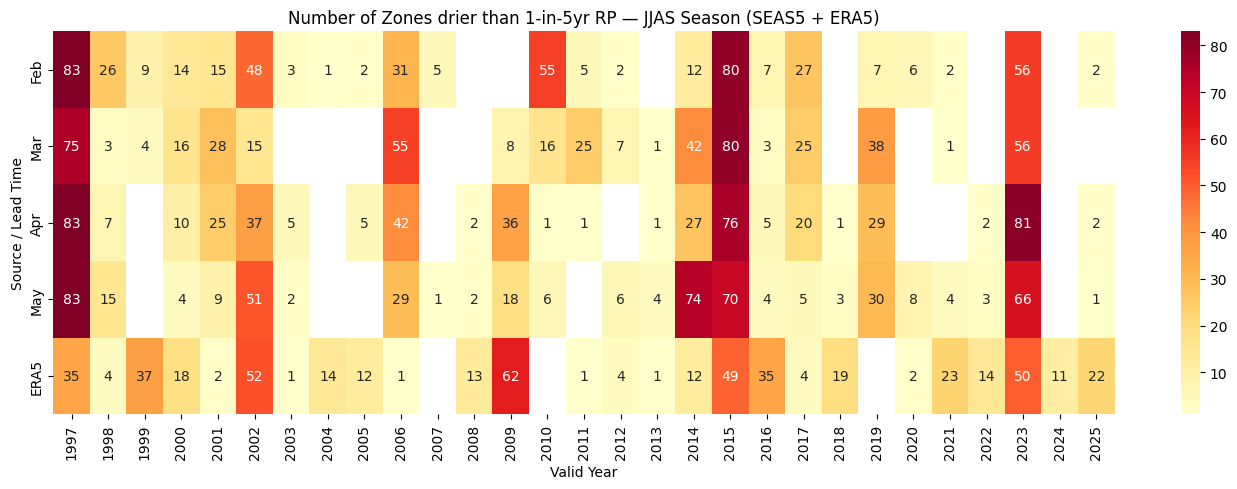

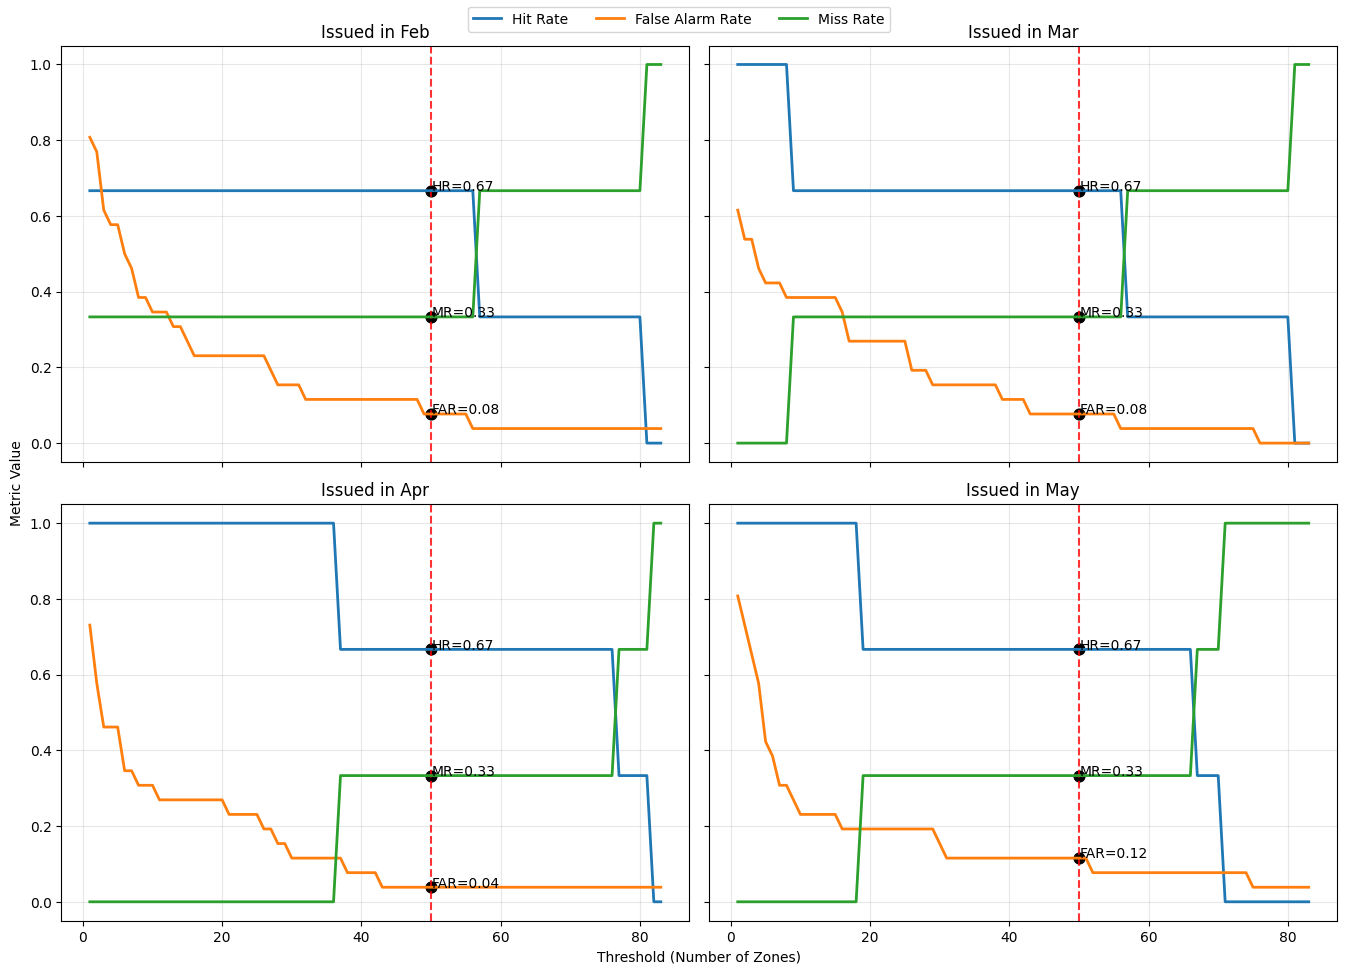

,year,era5_rainfall,Lead Time 4 (Feb),Lead Time 3 (Mar),Lead Time 2 (Apr),Lead Time 1 (May),ERA5 (Observed),CERF Allocations,People Affected
12,2009,1773,,8,36,18,62,,"6,200,000"
26,2023,1784,56,56,81,66,50,"17,000,001",
18,2015,1792,80,80,76,70,49,,"10,200,000"
5,2002,1808,48,15,37,51,52,,
0,1997,1872,,,,,,,
24,2021,1875,2,1,,4,23,,"6,800,000"
19,2016,1895,7,3,5,4,35,,
2,1999,1907,9,4,,,37,,
28,2025,1953,,,,,,,
7,2004,1957,1,,,,14,,


In [13]:
jjas_table = build_season_table(
    seas5_data=seas5_data,
    validation_csv=validation_csv,
    era5_data=era5_data,
    season_name="JJAS",
    season_months=[6, 7, 8, 9],
    lead_time_map={2: 4, 3: 3, 4: 2, 5: 1},
    plot_heatmap=True,
    plot_skill=True,
    highlight_value=50,
    N_events=3,
)

jjas_table

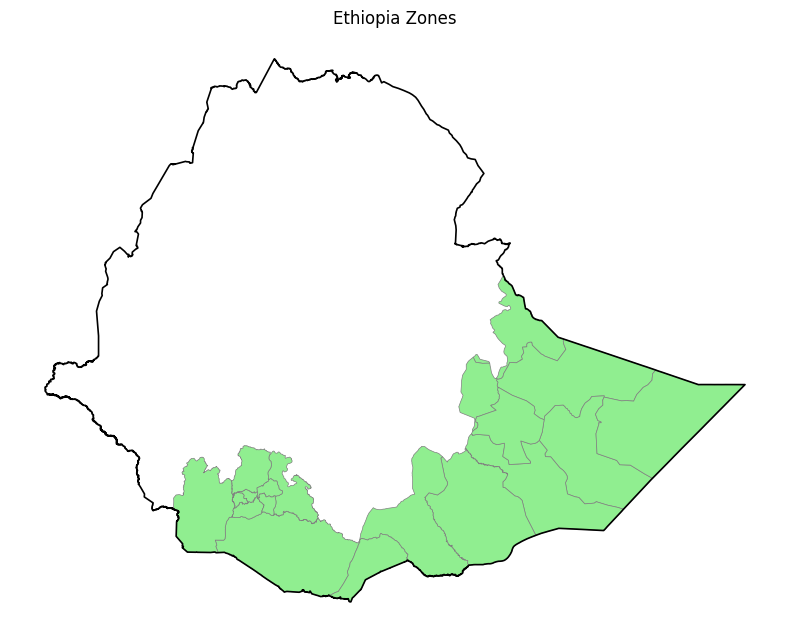

In [14]:
season_csv = stratus.load_csv_from_blob(
    ond_blob_name, stage="dev", container_name="projects"
)
seas5_data = fetch_seas5_data(
    season_csv["adm2_pcode"].unique(), start_date=start_date, end_date=end_date
)
era5_data = fetch_era5_data(
    season_csv["adm2_pcode"].unique(), start_date=start_date, end_date=end_date
)
era5_data["year"] = pd.to_datetime(era5_data["valid_date"]).dt.year
# validation data (CERF + EMDAT)
validation_csv = stratus.load_csv_from_blob(
    ond_validation_data, stage="dev", container_name="projects"
)
validation_csv["year"] = validation_csv["Season"].str[-4:].astype(int)
# plot the admins
fig, ax = plt.subplots(figsize=(8, 8))
eth_adm2[eth_adm2["adm2_src"].isin(season_csv["adm2_pcode"])].plot(
    ax=ax, edgecolor="grey", facecolor="lightgreen", linewidth=0.5
)
eth_adm0.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=1.2)
ax.set_title("Ethiopia Zones")
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [15]:
len(season_csv["adm2_pcode"].unique())

19

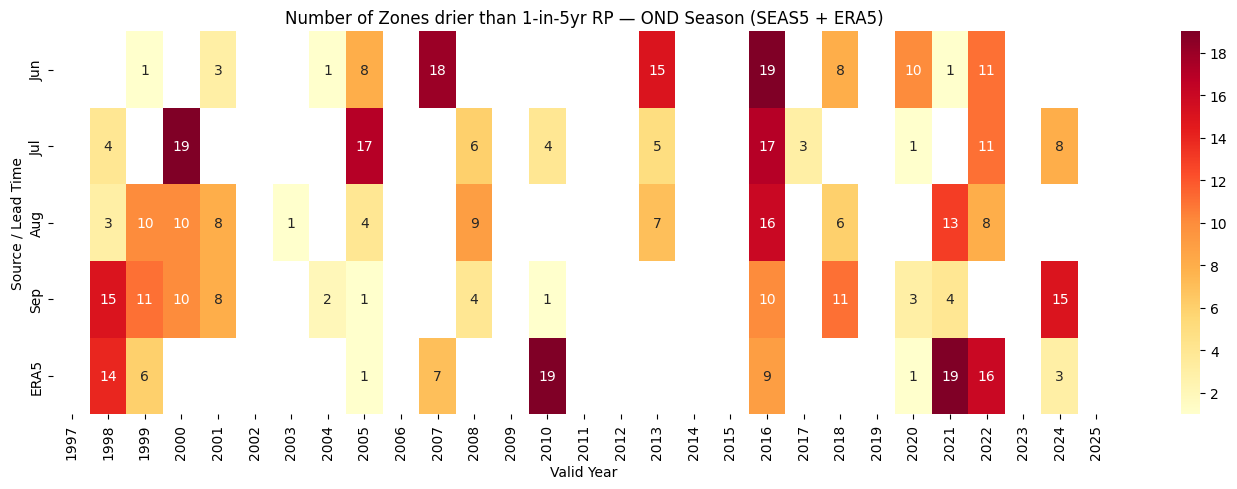

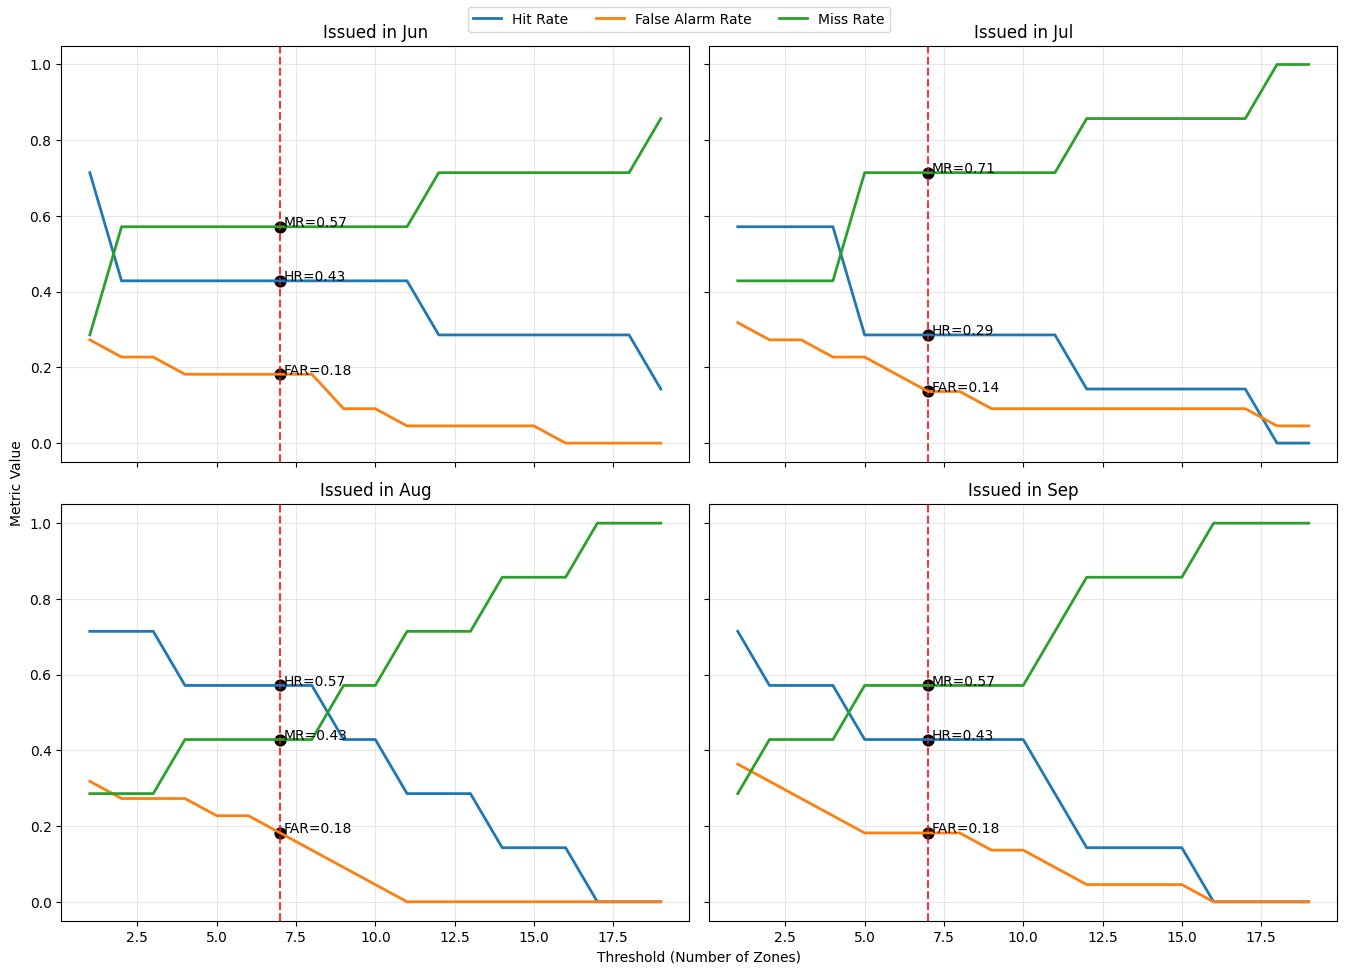

,year,era5_rainfall,Lead Time 4 (Jun),Lead Time 3 (Jul),Lead Time 2 (Aug),Lead Time 1 (Sep),ERA5 (Observed),CERF Allocations,People Affected
24,2021,44,1,,13,4,19,"4,987,750","6,800,000"
13,2010,52,,4,,1,19,,
25,2022,58,11,11,8,,16,,"24,100,000"
1,1998,65,,4,3,15,14,,
19,2016,75,19,17,16,10,9,"18,512,690",
10,2007,81,18,,,,7,,
2,1999,83,1,,10,11,6,,
8,2005,89,8,17,4,1,1,"3,978,239","2,600,000"
6,2003,97,,,1,,,,"12,600,000"
27,2024,106,,8,,15,3,"10,000,234",


In [16]:
ond_table = build_season_table(
    seas5_data=seas5_data,
    validation_csv=validation_csv,
    era5_data=era5_data,
    season_name="OND",
    season_months=[10, 11, 12],
    lead_time_map={6: 4, 7: 3, 8: 2, 9: 1},
    plot_heatmap=True,
    plot_skill=True,
    highlight_value=7,
    N_events=7,
)

ond_table

Let us test the maproom as well.


In [17]:
somali_mam_hindcast = stratus.load_csv_from_blob(
    somali_mam_maproom_hindcast, stage="dev", container_name="projects"
)
somali_mam_hindcast["Region"] = "Somali"
oromia_mam_hindcast = stratus.load_csv_from_blob(
    oromia_mam_maproom_hindcast, stage="dev", container_name="projects"
)
oromia_mam_hindcast["Region"] = "Oromia"
mam_maproom_hindcast = pd.concat([somali_mam_hindcast, oromia_mam_hindcast], axis=0)

In [18]:
def build_forecast_table(
    hindcast_df,
    issue_month_map,
    severity_filter="Severe",
    val_cols=("ENSO State", "Action Frequency"),
    plot_heatmap=False,
    plot_skill=False,
    highlight_value=None,
    N_events=7,
    drought_years=None,
):
    """
    Forecast analogue of build_season_table().
    - Count severe woredas per Issue Year + Issue Month
    - Heatmap identical in shape to SEAS5 drought heatmap
    - Metrics (HR, FAR, MR) based on driest N_events from NDVI or rainfall
    """

    df = hindcast_df.copy()

    df = df[(df["Severity"] == severity_filter) & (df["Triggered?"] == "Yes")].copy()

    severe_counts = (
        df.groupby(["Issue Year", "Issue Month"])
        .size()
        .reset_index(name="severe_count")
    )

    pivot = severe_counts.pivot_table(
        index="Issue Month", columns="Issue Year", values="severe_count", fill_value=0
    )
    all_years = sorted(hindcast_df["Issue Year"].unique())
    pivot = pivot.reindex(columns=all_years, fill_value=0)

    pivot.index = pivot.index.map(issue_month_map)

    pivot = pivot.groupby(pivot.index).sum()

    pivot = pivot.reindex(sorted(issue_month_map.values(), reverse=True))

    if plot_heatmap:

        plt.figure(figsize=(16, 4))
        sns.heatmap(pivot, annot=True, cmap="YlOrBr", fmt="g", linewidths=0.4)
        plt.title(
            "EMI/IRI WFP Maproom Hindcast Severe Threshold Woreda Counts (Somali + Oromia Regions)"
        )
        plt.xlabel("Issue Year")
        plt.ylabel("Lead Time")
        plt.tight_layout()
        plt.show()

    obs_event = pd.Series(
        [1 if y in drought_years else 0 for y in all_years], index=all_years
    )
    if plot_skill and isinstance(drought_years, list):

        if isinstance(drought_years, list):
            obs_event = pd.Series(
                [1 if y in drought_years else 0 for y in all_years], index=all_years
            )
        else:
            raise ValueError("observed_years must be a list of years")

        max_zones = int(pivot.values.max())
        thresholds = np.arange(1, max_zones + 1)

        lt_names = list(pivot.index)
        fig, axes = plt.subplots(
            1, len(lt_names), figsize=(5 * len(lt_names), 4), sharex=True, sharey=True
        )
        if len(lt_names) == 1:
            axes = [axes]

        for ax, lt_name in zip(axes, lt_names):

            fc_values = pivot.loc[lt_name].reindex(all_years)

            hit_rates = []
            false_rates = []
            miss_rates = []

            for T in thresholds:
                # Forecast event: ≥ T severe woredas
                fc = fc_values.apply(lambda z: 1 if z >= T else 0)

                obs = obs_event

                hits = ((fc == 1) & (obs == 1)).sum()
                misses = ((fc == 0) & (obs == 1)).sum()
                false_alarms = ((fc == 1) & (obs == 0)).sum()
                correct_neg = ((fc == 0) & (obs == 0)).sum()

                HR = hits / (hits + misses) if (hits + misses) else 0
                FAR = (
                    false_alarms / (false_alarms + correct_neg)
                    if (false_alarms + correct_neg)
                    else 0
                )
                MR = misses / (hits + misses) if (hits + misses) else 0

                hit_rates.append(HR)
                false_rates.append(FAR)
                miss_rates.append(MR)

            # Plot
            ax.plot(thresholds, hit_rates, label="Hit Rate")
            ax.plot(thresholds, false_rates, label="False Alarm Rate")
            ax.plot(thresholds, miss_rates, label="Miss Rate")

            # Highlight chosen threshold
            if highlight_value is not None:
                T = int(highlight_value)
                if T <= max(thresholds):
                    ax.axvline(T, color="red", linestyle="--")
                    ax.scatter([T], [hit_rates[T - 1]], color="black", s=50)
                    ax.scatter([T], [false_rates[T - 1]], color="black", s=50)
                    ax.scatter([T], [miss_rates[T - 1]], color="black", s=50)

            ax.set_title(f"{lt_name}")
            ax.grid(alpha=0.3)

        fig.supxlabel("Threshold (Number of Woredas reaching the Severe Threshold)")
        fig.supylabel("Metric Value")
        fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", ncol=3)

        plt.tight_layout(rect=[0, 0, 1, 0.92])
        plt.show()

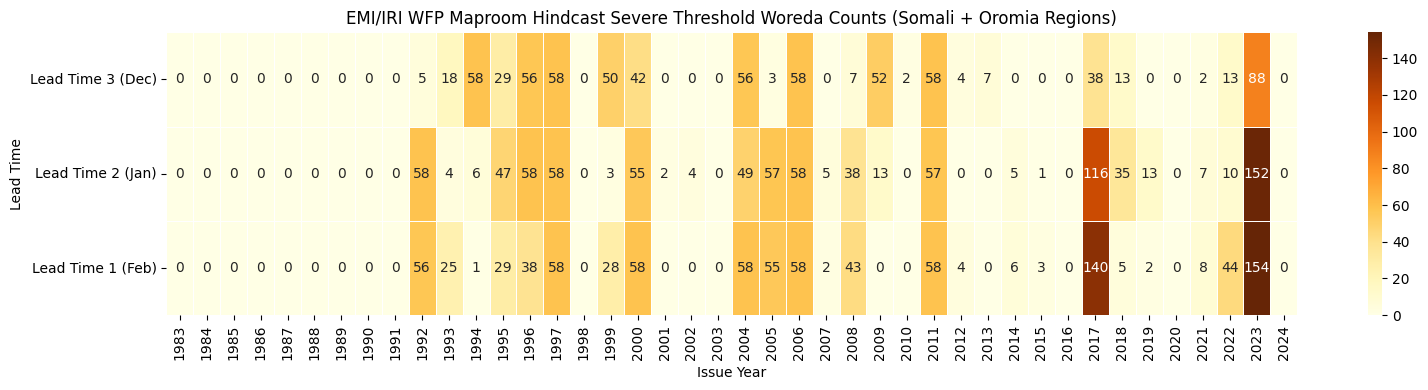

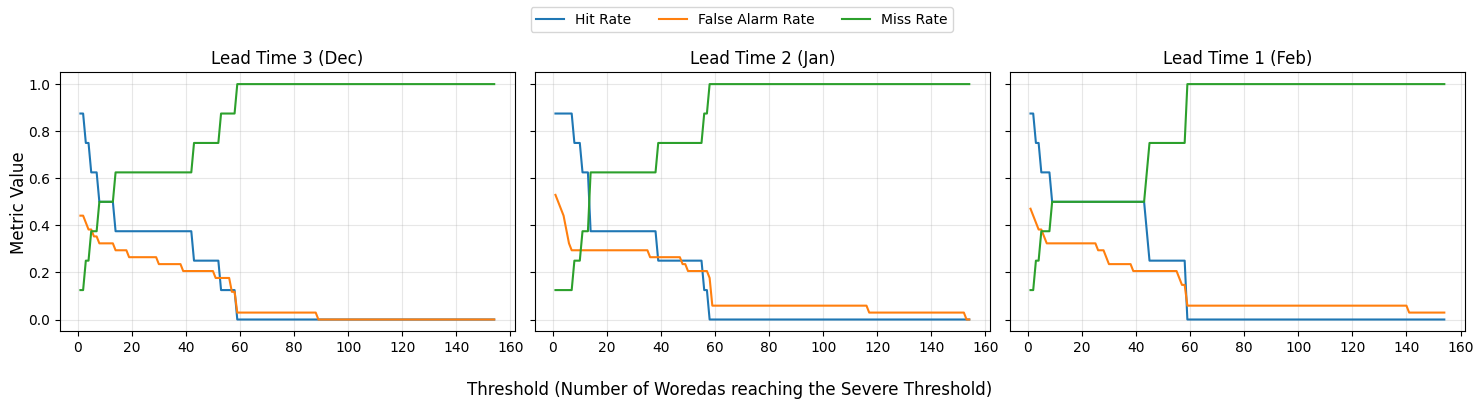

In [19]:
issue_month_map = {
    "Dec": "Lead Time 3 (Dec)",
    "Jan": "Lead Time 2 (Jan)",
    "Feb": "Lead Time 1 (Feb)",
}

forecast_heatmap = build_forecast_table(
    mam_maproom_hindcast,
    issue_month_map,
    severity_filter="Severe",
    val_cols=("ENSO State", "Action Frequency"),
    plot_heatmap=True,
    plot_skill=True,
    highlight_value=None,
    N_events=7,
    drought_years=[2022, 2009, 2000, 2008, 2021, 2011, 2019, 2012],
)

In [20]:
somali_ond_hindcast = stratus.load_csv_from_blob(
    somali_ond_maproom_hindcast, stage="dev", container_name="projects"
)
somali_ond_hindcast["Region"] = "Somali"
oromia_ond_hindcast = stratus.load_csv_from_blob(
    oromia_ond_maproom_hindcast, stage="dev", container_name="projects"
)
oromia_ond_hindcast["Region"] = "Oromia"
ond_maproom_hindcast = pd.concat([somali_ond_hindcast, oromia_ond_hindcast], axis=0)

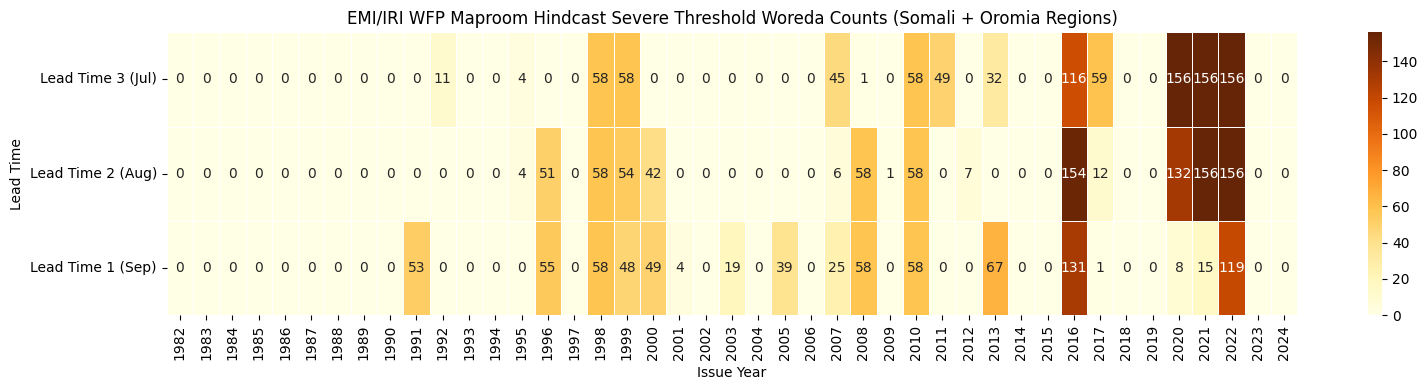

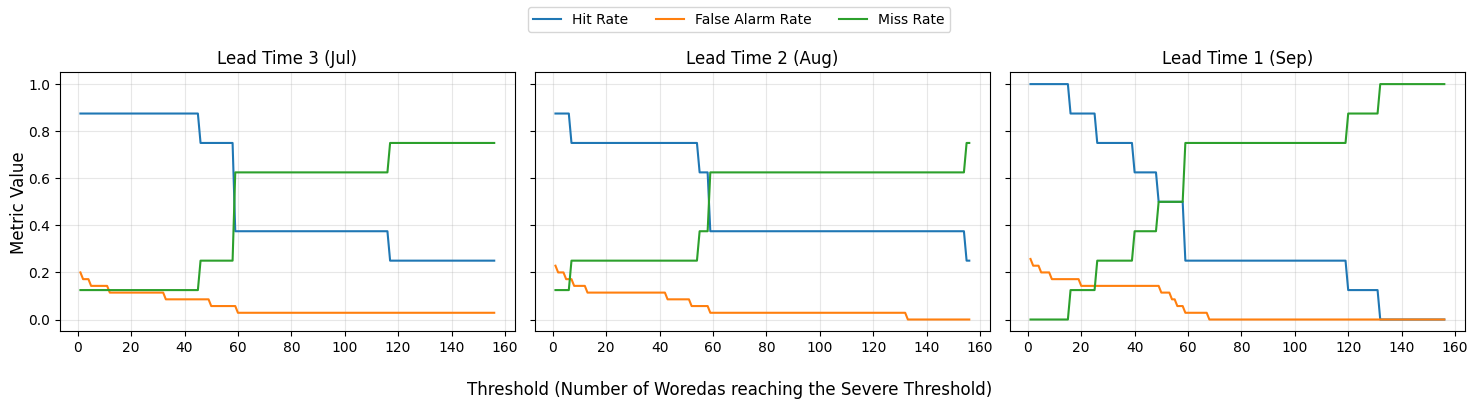

In [21]:
issue_month_map = {
    "Jul": "Lead Time 3 (Jul)",
    "Aug": "Lead Time 2 (Aug)",
    "Sep": "Lead Time 1 (Sep)",
}

forecast_heatmap = build_forecast_table(
    ond_maproom_hindcast,
    issue_month_map,
    severity_filter="Severe",
    val_cols=("ENSO State", "Action Frequency"),
    plot_heatmap=True,
    plot_skill=True,
    highlight_value=None,
    N_events=7,
    drought_years=[2021, 2010, 2022, 1998, 2016, 2007, 1999, 2005],
)